# Multi-Oracle Active Learning — Sentimen Komentar YouTube MBG
## IndoBERT embeddings + LinearSVC · tiga oracle (A/B/C) dengan entropy-based routing

Notebook eksperimen untuk paper *Adaptive Multi-Oracle Active Learning using IndoBERT Representations for Efficient Indonesian Sentiment Classification* (ICERA 2026, IEEE).

**Data** diletakkan di folder `data/` (atau di Google Drive `MyDrive/MBG_AL` bila memakai Colab).
**Urutan:** jalankan sel dari atas ke bawah. Sel eksperimen dipisah per konfigurasi sehingga dapat dijalankan ulang secara parsial; hasil tiap sel ditambahkan ke `ALL_RESULTS`.

| Eksperimen | Konfigurasi | Perkiraan waktu |
|---|---|---|
| Pra-komputasi embedding | wajib dijalankan sekali | — |
| Oracle B | 5 strategi × 3 seed | ±20 menit |
| Oracle A | 5 strategi × 3 seed | ±3 menit |
| Multi-Oracle **dengan** bobot sampel | 5 strategi × 3 seed | ±80 menit (GPU) |
| Multi-Oracle **tanpa** bobot sampel | 5 strategi × 3 seed (ablasi) | ±80 menit (GPU) |


## Cell 1 — Mount Google Drive & Instalasi

In [1]:
import os
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm openpyxl scipy -q

# Lokasi data & output.
#  - Lokal / Colab (repo di-clone)  : data/  -> outputs/
#  - Colab + Google Drive           : MyDrive/MBG_AL (bila foldernya ada)
DATA_DIR   = 'data'
OUTPUT_DIR = 'outputs'
if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    if os.path.isdir('/content/drive/MyDrive/MBG_AL'):
        DATA_DIR   = '/content/drive/MyDrive/MBG_AL'
        OUTPUT_DIR = '/content/drive/MyDrive/MBG_AL/output'

INDOBERT_POOL_PATH = f'{DATA_DIR}/labeled_indobert_mbg.csv'
HUMAN_LABELED_PATH = f'{DATA_DIR}/sample_999_labeled.csv'

for p in [INDOBERT_POOL_PATH, HUMAN_LABELED_PATH]:
    status = '✅' if os.path.exists(p) else '❌ TIDAK DITEMUKAN — letakkan file di folder data/ (atau Drive/MBG_AL)'
    print(f'{status}  {p}')
print("\n✅ Siap. Lanjutkan ke sel berikutnya.")


Mounted at /content/drive
✅  /content/drive/MyDrive/MBG_AL/labeled_indobert_mbg.csv
✅  /content/drive/MyDrive/MBG_AL/sample_999_labeled.csv

✅ Siap. Lanjutkan ke Cell 2.


## Cell 2 — Imports

In [2]:
import os, re, time, warnings, tracemalloc, unicodedata
from collections import Counter
import numpy as np
import pandas as pd
from scipy import stats
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import (accuracy_score, f1_score,
    classification_report, confusion_matrix, pairwise_distances)
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Device: {DEVICE}")
if DEVICE != 'cuda':
    print("⚠️  GPU tidak aktif! Runtime → Change runtime type → T4 GPU")

plt.rcParams.update({
    'figure.dpi':150,'savefig.dpi':300,'font.family':'DejaVu Sans','font.size':9,
    'axes.titlesize':9,'axes.labelsize':8,'xtick.labelsize':7,'ytick.labelsize':7,
    'legend.fontsize':7,'lines.linewidth':1.4,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,
})

✅ Device: cuda


## Cell 3 — Konfigurasi Global

In [3]:
# ── Desain eksperimen ──────────────────────────────────────────────────────────
N_TEST           = 700
N_ORACLE_A_POOL  = 299
N_SEED           = 100
AL_BATCH         = 50
RANDOM_SEED      = 42
RUN_SEEDS        = [42, 123, 456]

MAX_BUDGET       = 1500   # multi-oracle & Oracle B
MAX_BUDGET_A     = 200    # Oracle A (budget < pool ~209)

TH_HIGH = 0.65
TH_MID  = 0.50
ORACLE_WEIGHTS = {'A': 1.0, 'B': 0.3, 'C': 0.7}

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_NAME        = 'Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis'
EMBED_BATCH       = 32
FINETUNE_EPOCHS   = 3
FINETUNE_LR       = 2e-5
MIN_C_TRAIN_SIZE  = 100
UPDATE_C_INTERVAL = 64
SVM_C             = 1.0

# ── Label mapping ──────────────────────────────────────────────────────────────
LABEL_ORDER = ['Negative', 'Neutral', 'Positive']
ENCODE_MAP  = {
    'Negatif':0,'Netral':1,'Positif':2,
    'Negative':0,'Neutral':1,'Positive':2,
    'negatif':0,'netral':1,'positif':2,
}
DECODE_MAP  = {0:'Negative',1:'Neutral',2:'Positive'}

oracle_lbls  = {'multi':'Multi-Oracle (A+B+C)','indobert':'Oracle B','manual':'Oracle A'}
oracle_lbls_w = {'multi_w':'Multi-Oracle (bobot)','multi_nw':'Multi-Oracle (tanpa bobot)'}
ORACLE_COLOR = {'multi':'#e377c2','indobert':'#1f77b4','manual':'#2ca02c',
                'multi_w':'#e377c2','multi_nw':'#bcbd22'}
STRATEGY_COLOR = {
    'entropy':'#d62728','least_confidence':'#ff7f0e',
    'margin_sampling':'#e377c2','kcenter_greedy':'#9467bd','random':'#7f7f7f',
}

# ── Dict hasil — diisi per cell eksperimen ─────────────────────────────────────
ALL_RESULTS = {}

print('✅ Konfigurasi dimuat.')
print(f'   ALL_RESULTS diinisialisasi (dict kosong, akan diisi per cell)')
print(f'   RUN_SEEDS={RUN_SEEDS} | N_SEED={N_SEED} | AL_BATCH={AL_BATCH}')
print(f'   MAX_BUDGET={MAX_BUDGET} | MAX_BUDGET_A={MAX_BUDGET_A}')

✅ Konfigurasi dimuat.
   ALL_RESULTS diinisialisasi (dict kosong, akan diisi per cell)
   RUN_SEEDS=[42, 123, 456] | N_SEED=100 | AL_BATCH=50
   MAX_BUDGET=1500 | MAX_BUDGET_A=200


## Cell 4 — Helper Preprocessing

In [4]:
def make_text_processed(series):
    return (series.fillna('').astype(str)
            .str.lower()
            .str.replace(r'[^a-z\s]', ' ', regex=True)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip())
print('✅ make_text_processed() ready.')

✅ make_text_processed() ready.


## Cell 5 — Load Data & Split

In [5]:
df_human = pd.read_csv(HUMAN_LABELED_PATH, encoding='latin1', sep=';')
df_human['label_enc'] = df_human['sentiment'].map(ENCODE_MAP)
df_human = df_human.dropna(subset=['label_enc']).reset_index(drop=True)
df_human['label_enc'] = df_human['label_enc'].astype(int)
raw_col  = 'text_clean' if 'text_clean' in df_human.columns else 'text'
df_human['text_processed'] = make_text_processed(df_human[raw_col])

df_test, df_oracle_a_pool = train_test_split(
    df_human, test_size=N_ORACLE_A_POOL, random_state=RANDOM_SEED,
    stratify=df_human['label_enc'])
df_test          = df_test.reset_index(drop=True)
df_oracle_a_pool = df_oracle_a_pool.reset_index(drop=True)
X_test_text = df_test['text_processed'].values
y_test      = df_test['label_enc'].values

df_pool_full = pd.read_csv(INDOBERT_POOL_PATH, encoding='utf-8-sig', sep=',')
if 'text_processed' not in df_pool_full.columns:
    tc = next((c for c in df_pool_full.columns if 'text' in c.lower()), df_pool_full.columns[0])
    df_pool_full['text_processed'] = make_text_processed(df_pool_full[tc])
if 'label_enc' not in df_pool_full.columns:
    df_pool_full['label_enc'] = df_pool_full['sentiment'].map(ENCODE_MAP).astype(int)

test_set      = set(df_test['text_processed'].str.strip().values)
df_train_pool = df_pool_full[
    ~df_pool_full['text_processed'].str.strip().isin(test_set)
].reset_index(drop=True)

print(f'✅ Test set      : {len(df_test)} (ground truth manusia)')
print(f'✅ Oracle A pool : {len(df_oracle_a_pool)} (manusia, training)')
print(f'✅ Training pool : {len(df_train_pool):,} (IndoBERT pseudo-labels)')
for k in [0,1,2]:
    n = (y_test==k).sum()
    print(f'   Test {DECODE_MAP[k]:10s}: {n} ({n/len(y_test)*100:.1f}%)')
for k in [0,1,2]:
    n = (df_train_pool['label_enc']==k).sum()
    print(f'   Pool {DECODE_MAP[k]:10s}: {n} ({n/len(df_train_pool)*100:.1f}%)')

✅ Test set      : 700 (ground truth manusia)
✅ Oracle A pool : 299 (manusia, training)
✅ Training pool : 7,956 (IndoBERT pseudo-labels)
   Test Negative  : 279 (39.9%)
   Test Neutral   : 280 (40.0%)
   Test Positive  : 141 (20.1%)
   Pool Negative  : 5261 (66.1%)
   Pool Neutral   : 1446 (18.2%)
   Pool Positive  : 1249 (15.7%)


## Cell 6 — Load IndoBERT & Filtering Pool conf≥0.70

In [6]:
print(f'Loading: {MODEL_NAME}')
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model_bert.eval()
print('✅ Model loaded.')

probs_list = []
with torch.no_grad():
    for i in tqdm(range(0, len(df_train_pool), 32), desc='Confidence scoring', leave=False):
        batch = df_train_pool['text_processed'].values[i:i+32]
        enc   = tokenizer_bert(list(batch), padding=True, truncation=True,
                               max_length=128, return_tensors='pt').to(DEVICE)
        probs_list.append(torch.softmax(model_bert(**enc).logits, dim=-1).cpu().numpy())

probs_pool_raw = np.vstack(probs_list)
conf           = probs_pool_raw.max(axis=1)
mask           = conf >= 0.70
df_train_pool  = df_train_pool[mask].reset_index(drop=True)

print(f'✅ Pool setelah filtering: {len(df_train_pool):,} ({mask.mean()*100:.1f}%)')
for k in [0,1,2]:
    n = (df_train_pool['label_enc']==k).sum()
    print(f'   {DECODE_MAP[k]:10s}: {n:5d} ({n/len(df_train_pool)*100:.1f}%)')

Loading: Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis


config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded.


✅ Pool setelah filtering: 7,253 (91.2%)
   Negative  :  4942 (68.1%)
   Neutral   :  1221 (16.8%)
   Positive  :  1090 (15.0%)


## Cell 7 — Oracle A: Pencocokan Label Manusia

In [7]:
def norm_text(t):
    t = str(t).strip()
    t = unicodedata.normalize('NFKC', t)
    return t.replace('\r\n','\n').replace('\r','\n')

oracle_a_dict = {norm_text(row['text']): int(row['label_enc'])
                 for _, row in df_oracle_a_pool.iterrows()}
pool_norms = [norm_text(t) for t in df_train_pool['text'].fillna('').astype(str)]
oracle_A   = np.full(len(df_train_pool), -1, dtype=int)
for i, t in enumerate(pool_norms):
    if t in oracle_a_dict:
        oracle_A[i] = oracle_a_dict[t]

n_a = int((oracle_A >= 0).sum())
print(f'✅ oracle_A: {n_a} posisi valid dari {len(df_train_pool):,} pool')
dist_a = Counter(oracle_A[oracle_A>=0].tolist())
for k in [0,1,2]:
    print(f'   {DECODE_MAP[k]:10s}: {dist_a[k]} ({dist_a[k]/n_a*100:.1f}%)')
print(f'\n   Rasio Oracle A dalam pool: {n_a/len(df_train_pool)*100:.2f}%')
print(f'   MAX_BUDGET_A={MAX_BUDGET_A} vs pool={n_a}')
if MAX_BUDGET_A >= int(n_a * 0.90):
    print(f'   ⚠️  Budget Oracle A ({MAX_BUDGET_A}) ≈ pool ({n_a})')
    print(f'   → Strategi AL tidak akan beda jauh dengan random pada Oracle A')
    print(f'   → Ini NORMAL dan akan dilaporkan sebagai temuan RQ1')

✅ oracle_A: 201 posisi valid dari 7,253 pool
   Negative  : 78 (38.8%)
   Neutral   : 78 (38.8%)
   Positive  : 45 (22.4%)

   Rasio Oracle A dalam pool: 2.77%
   MAX_BUDGET_A=200 vs pool=201
   ⚠️  Budget Oracle A (200) ≈ pool (201)
   → Strategi AL tidak akan beda jauh dengan random pada Oracle A
   → Ini NORMAL dan akan dilaporkan sebagai temuan RQ1


## Cell 8 — SVM Adaptif & Query Strategies

**FIX CalibratedClassifierCV error:**
`build_classifier(y_train)` mengecek minimum sampel per kelas sebelum memilih SVM atau LR fallback.

In [8]:
def query_entropy(probs, n, **kw):
    eps = 1e-10
    return np.argsort(-(-np.sum(probs*np.log(probs+eps), axis=1)))[:n]

def query_least_confidence(probs, n, **kw):
    return np.argsort(probs.max(axis=1))[:n]

def query_margin(probs, n, **kw):
    sp = np.sort(probs, axis=1)[:, ::-1]
    return np.argsort(sp[:,0] - sp[:,1])[:n]

def query_kcenter(probs, n, emb_labeled=None, emb_pool=None, **kw):
    if emb_labeled is None or emb_pool is None:
        return query_entropy(probs, n)
    dists = pairwise_distances(emb_pool, emb_labeled, metric='euclidean').min(axis=1)
    selected = []
    for _ in range(n):
        idx = int(np.argmax(dists)); selected.append(idx)
        dists = np.minimum(dists, np.linalg.norm(emb_pool - emb_pool[idx], axis=1))
    return np.array(selected)

def query_random(probs, n, rng=None, **kw):
    rng = rng or np.random.RandomState()
    return rng.choice(len(probs), n, replace=False)

STRATEGIES = {
    'entropy':          query_entropy,
    'least_confidence': query_least_confidence,
    'margin_sampling':  query_margin,
    'kcenter_greedy':   query_kcenter,
}

def build_classifier(y_train=None):
    """
    SVM adaptif:
    - min kelas >= 2 sampel → CalibratedClassifierCV(LinearSVC, cv=2)  [optimal]
    - ada kelas < 2 sampel  → LogisticRegression fallback               [stabil]
    """
    use_svm = True
    if y_train is not None:
        counts    = Counter(int(v) for v in y_train if v >= 0)
        min_count = min(counts.get(k, 0) for k in [0, 1, 2])
        if min_count < 2:
            use_svm = False

    if use_svm:
        base = LinearSVC(C=SVM_C, class_weight='balanced', max_iter=3000,
                         random_state=RANDOM_SEED, dual='auto')
        return CalibratedClassifierCV(base, cv=2, method='sigmoid')
    else:
        return LogisticRegression(C=5, max_iter=2000, class_weight='balanced',
                                   solver='saga', multi_class='multinomial',
                                   random_state=RANDOM_SEED, n_jobs=-1)

def evaluate(clf, X, y):
    yp = clf.predict(X)
    result = {
        'accuracy':    float(accuracy_score(y, yp)),
        'f1_macro':    float(f1_score(y, yp, average='macro',    zero_division=0)),
        'f1_weighted': float(f1_score(y, yp, average='weighted', zero_division=0)),
    }
    for k, v in enumerate(f1_score(y, yp, average=None, zero_division=0, labels=[0,1,2])):
        result[f'f1_class{k}'] = float(v)
    return result

# Verifikasi
_X = np.random.randn(30, 5); _y = np.array([0]*10+[1]*10+[2]*10)
_clf = build_classifier(y_train=_y); _clf.fit(_X, _y)
assert hasattr(_clf, 'predict_proba')
_y_small = np.array([0]*5+[1]*5+[2]*1)
_clf2 = build_classifier(y_train=_y_small)
print(f'✅ SVM case : {type(_clf.estimator).__name__} + CalibratedCV')
print(f'✅ LR  case : {type(_clf2).__name__} (kelas min < 2)')
print(f'✅ Strategies: {list(STRATEGIES.keys())} + random')

✅ SVM case : LinearSVC + CalibratedCV
✅ LR  case : LogisticRegression (kelas min < 2)
✅ Strategies: ['entropy', 'least_confidence', 'margin_sampling', 'kcenter_greedy'] + random


## Cell 9 — BertFineTuner (Oracle C)

In [9]:
class BertFineTuner:
    def __init__(self, epochs=3, lr=2e-5):
        self.epochs=epochs; self.lr=lr; self.model=None

    def _encode(self, texts, labels=None, bs=32):
        all_ids, all_mask = [], []
        for i in range(0, len(texts), bs):
            enc = tokenizer_bert(list(texts[i:i+bs]), padding='max_length',
                                 truncation=True, max_length=128, return_tensors='pt')
            all_ids.append(enc['input_ids']); all_mask.append(enc['attention_mask'])
        ids, mask = torch.cat(all_ids), torch.cat(all_mask)
        if labels is not None:
            return TensorDataset(ids, mask, torch.tensor(labels, dtype=torch.long))
        return TensorDataset(ids, mask)

    def fit(self, texts, labels, sample_weight=None):
        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True).to(DEVICE)
        loader = DataLoader(self._encode(texts, labels), batch_size=16, shuffle=True)
        opt    = AdamW(self.model.parameters(), lr=self.lr, weight_decay=0.01)
        sch    = get_linear_schedule_with_warmup(opt, 0, self.epochs*len(loader))
        self.model.train()
        for _ in range(self.epochs):
            for batch in loader:
                ids, mask, lab = [b.to(DEVICE) for b in batch]
                loss = self.model(input_ids=ids, attention_mask=mask, labels=lab).loss
                loss.backward(); opt.step(); sch.step(); opt.zero_grad()
        return self

    def predict(self, texts):
        return np.argmax(self.predict_proba(texts), axis=1)

    def predict_proba(self, texts):
        self.model.eval(); probs = []
        with torch.no_grad():
            for batch in DataLoader(self._encode(texts), batch_size=32):
                ids, mask = [b.to(DEVICE) for b in batch]
                probs.append(torch.softmax(
                    self.model(input_ids=ids, attention_mask=mask).logits,
                    dim=-1).cpu().numpy())
        return np.vstack(probs)

print(f'✅ BertFineTuner ready. Oracle C aktif: {DEVICE == "cuda"}')

✅ BertFineTuner ready. Oracle C aktif: True


## Cell 10 — Helpers: select_oracle, init_labeled_set, make_seed_indices

**FIX Oracle A bug:**
`make_seed_indices` sekarang benar-benar memfilter ke posisi oracle_A valid ketika `oracle_A_arr` diberikan.
Sebelumnya parameter ini diterima tapi diabaikan → seed 98% berisi -1 → F1=0.000.

In [10]:
def select_oracle(idx, entropy_val, oracle_A, oracle_B, model_C=None,
                  usage=None, rng=None, max_ratio_A=0.25, max_ratio_C=0.35):
    if usage is None: usage = {'A':0,'B':0,'C':0}
    if rng   is None: rng   = np.random.RandomState()
    total   = max(sum(usage.values()), 1)
    ratio_A = usage['A'] / total
    ratio_C = usage['C'] / total
    pred_B  = int(oracle_B[idx])
    pred_C  = None
    if model_C is not None:
        try:
            pred_C = int(model_C.predict([df_train_pool['text_processed'].values[idx]])[0])
        except: pass

    if entropy_val > TH_HIGH:
        if oracle_A[idx] >= 0 and ratio_A < max_ratio_A:
            return int(oracle_A[idx]), 'A'
        if pred_C is not None and ratio_C < max_ratio_C:
            return pred_C, 'C'
        return pred_B, 'B'
    elif entropy_val > TH_MID:
        if pred_C is not None and ratio_C < max_ratio_C and rng.rand() < 0.60:
            return pred_C, 'C'
        if oracle_A[idx] >= 0 and ratio_A < max_ratio_A and rng.rand() < 0.20:
            return int(oracle_A[idx]), 'A'
        return pred_B, 'B'
    else:
        if pred_C is not None and ratio_C < max_ratio_C and rng.rand() < 0.10:
            return pred_C, 'C'
        return pred_B, 'B'


def init_labeled_set(seed_indices, oracle_A, oracle_B):
    labels, label_source = {}, {}
    for idx in seed_indices:
        if oracle_A[idx] >= 0:
            labels[idx]       = int(oracle_A[idx])
            label_source[idx] = 'A'
        else:
            labels[idx]       = int(oracle_B[idx])
            label_source[idx] = 'B'
    return labels, label_source


def make_seed_indices(df_pool, n_seed, run_seed, oracle_A_arr=None):
    """
    FIX: Jika oracle_A_arr diberikan, seed HANYA dipilih dari posisi
    yang punya label valid (oracle_A_arr[i] >= 0).
    """
    rng       = np.random.RandomState(run_seed)
    result    = []
    per_class = n_seed // 3
    for k in [0, 1, 2]:
        if oracle_A_arr is not None:
            idx_k = np.where(
                (df_pool['label_enc'].values == k) & (oracle_A_arr >= 0)
            )[0]
        else:
            idx_k = np.where(df_pool['label_enc'].values == k)[0]
        if len(idx_k) == 0:
            continue
        n_take = min(per_class, len(idx_k))
        chosen = rng.choice(idx_k, n_take, replace=False)
        result.extend(chosen.tolist())
    return np.array(result[:n_seed])


print('✅ select_oracle(), init_labeled_set() ready.')
print('✅ make_seed_indices() — FIX oracle_A_arr filter aktif.')

# Verifikasi fix
_seed = make_seed_indices(df_train_pool, N_SEED, 42, oracle_A_arr=oracle_A)
_y_check = oracle_A[_seed]
n_invalid = (_y_check < 0).sum()
print(f'\nVerifikasi seed Oracle A (seed=42):')
print(f'   Total seed     : {len(_seed)}')
print(f'   Valid labels   : {(_y_check>=0).sum()} ← harus = total seed')
print(f'   Nilai -1 (bug) : {n_invalid} ← harus = 0')
if n_invalid == 0:
    print('   ✅ BUG FIXED — tidak ada nilai -1 dalam seed Oracle A')
else:
    print(f'   ❌ Masih ada {n_invalid} nilai -1 — cek ulang!')

✅ select_oracle(), init_labeled_set() ready.
✅ make_seed_indices() — FIX oracle_A_arr filter aktif.

Verifikasi seed Oracle A (seed=42):
   Total seed     : 99
   Valid labels   : 99 ← harus = total seed
   Nilai -1 (bug) : 0 ← harus = 0
   ✅ BUG FIXED — tidak ada nilai -1 dalam seed Oracle A


## Cell 11 — Loop Multi-Oracle AL (SVM adaptif)

In [11]:
def run_multi_oracle_al(strategy_name, oracle_A, oracle_B, seed_indices,
                        max_budget, run_seed=42, use_sample_weight=True):
    rng = np.random.RandomState(run_seed)
    history, oracle_history = [], []
    labels, label_source = init_labeled_set(seed_indices, oracle_A, oracle_B)
    labeled_idx    = list(labels.keys())
    unlabeled_mask = np.ones(len(df_train_pool), dtype=bool)
    for idx in labeled_idx: unlabeled_mask[idx] = False
    model_C = None; last_update_C = 0
    usage_counter = {'A':0,'B':0,'C':0}

    while len(labeled_idx) < max_budget:
        pool_idx = np.where(unlabeled_mask)[0]
        if len(pool_idx) < AL_BATCH: break

        y_L = np.array([labels[i] for i in labeled_idx])
        X_L = pool_embeddings[labeled_idx]
        sw  = (np.array([ORACLE_WEIGHTS[label_source[i]] for i in labeled_idx])
               if use_sample_weight else None)

        clf = build_classifier(y_train=y_L)
        clf.fit(X_L, y_L, sample_weight=sw)

        if DEVICE == 'cuda' and len(labeled_idx) >= MIN_C_TRAIN_SIZE:
            if model_C is None or (len(labeled_idx) - last_update_C >= UPDATE_C_INTERVAL):
                try:
                    model_C = BertFineTuner(epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR)
                    model_C.fit(df_train_pool['text_processed'].values[labeled_idx], y_L)
                    last_update_C = len(labeled_idx)
                except: model_C = None

        metrics = evaluate(clf, test_embeddings, y_test)
        oc      = Counter(label_source.values())
        metrics.update({
            'n_labeled':  len(labeled_idx),
            'n_oracle_A': oc.get('A',0),
            'n_oracle_B': oc.get('B',0),
            'n_oracle_C': oc.get('C',0),
        })
        history.append(metrics)
        oracle_history.append(dict(usage_counter))

        probs     = clf.predict_proba(pool_embeddings[pool_idx])
        eps       = 1e-10
        entropies = -np.sum(probs*np.log(probs+eps), axis=1)

        q_local = (query_random(probs, AL_BATCH, rng=rng) if strategy_name == 'random'
                   else STRATEGIES[strategy_name](probs, AL_BATCH,
                        emb_labeled=pool_embeddings[labeled_idx],
                        emb_pool=pool_embeddings[pool_idx]))

        for li in q_local:
            g_idx = int(pool_idx[li])
            lbl, src = select_oracle(g_idx, float(entropies[li]),
                                     oracle_A, oracle_B, model_C,
                                     usage=usage_counter, rng=rng)
            labels[g_idx]       = lbl
            label_source[g_idx] = src
            usage_counter[src] += 1
            labeled_idx.append(g_idx)
            unlabeled_mask[g_idx] = False

    y_Lf      = np.array([labels[i] for i in labeled_idx])
    swf       = (np.array([ORACLE_WEIGHTS[label_source[i]] for i in labeled_idx])
                 if use_sample_weight else None)
    final_clf = build_classifier(y_train=y_Lf)
    final_clf.fit(pool_embeddings[labeled_idx], y_Lf, sample_weight=swf)
    return {'history':history,'oracle_history':oracle_history,
            'label_source':label_source,'labeled_idx':labeled_idx,'final_clf':final_clf}

print('✅ run_multi_oracle_al() ready.')

✅ run_multi_oracle_al() ready.


## Cell 12 — Loop Single-Oracle AL (SVM adaptif + FIX filter -1)

In [12]:
def run_single_oracle_al(strategy_name, oracle_labels, seed_indices,
                          max_budget, run_seed=42):
    """
    FIX: Filter labeled_idx ke posisi oracle valid (>= 0) sebelum clf.fit().
    """
    rng = np.random.RandomState(run_seed)
    history = []
    labeled_idx    = list(seed_indices)
    unlabeled_mask = np.ones(len(df_train_pool), dtype=bool)
    for idx in labeled_idx: unlabeled_mask[idx] = False

    while len(labeled_idx) < max_budget:
        valid_mask = unlabeled_mask & (oracle_labels >= 0)
        pool_idx   = np.where(valid_mask)[0]
        if len(pool_idx) < AL_BATCH: break

        valid_labeled = [i for i in labeled_idx if oracle_labels[i] >= 0]
        y_L           = oracle_labels[valid_labeled]
        X_L           = pool_embeddings[valid_labeled]

        tracemalloc.start(); t0 = time.perf_counter()
        clf = build_classifier(y_train=y_L)
        clf.fit(X_L, y_L)
        train_sec = time.perf_counter() - t0
        _, mp = tracemalloc.get_traced_memory(); tracemalloc.stop()

        metrics = evaluate(clf, test_embeddings, y_test)
        metrics.update({'n_labeled':len(valid_labeled),
                        'train_sec':train_sec, 'mem_mb':mp/1024/1024})
        history.append(metrics)

        probs   = clf.predict_proba(pool_embeddings[pool_idx])
        q_local = (query_random(probs, AL_BATCH, rng=rng) if strategy_name == 'random'
                   else STRATEGIES[strategy_name](probs, AL_BATCH,
                        emb_labeled=pool_embeddings[valid_labeled],
                        emb_pool=pool_embeddings[pool_idx]))

        for idx in pool_idx[q_local]:
            labeled_idx.append(int(idx)); unlabeled_mask[int(idx)] = False

    valid_final = [i for i in labeled_idx if oracle_labels[i] >= 0]
    y_Lf        = oracle_labels[valid_final]
    final_clf   = build_classifier(y_train=y_Lf)
    final_clf.fit(pool_embeddings[valid_final], y_Lf)
    return {'history':history,'final_clf':final_clf,'labeled_idx':labeled_idx}

print('✅ run_single_oracle_al() ready — FIX filter -1 aktif.')

✅ run_single_oracle_al() ready — FIX filter -1 aktif.


## Cell 13 — EDA (opsional, bisa dilewati)

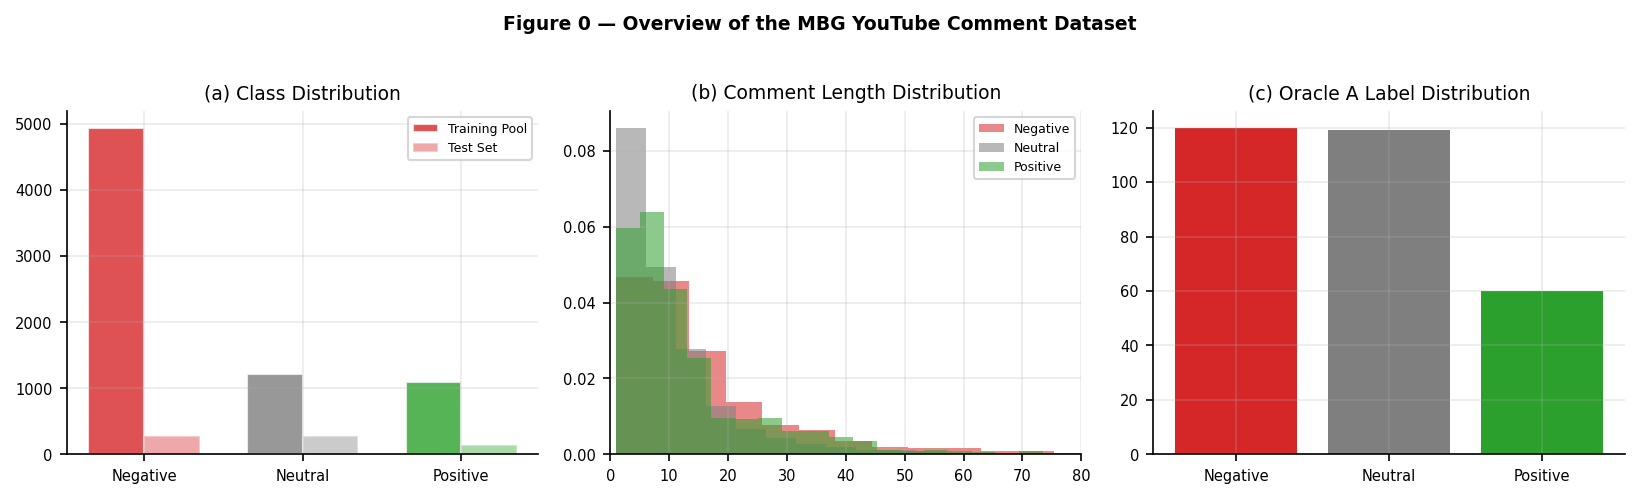

Figure 0 successfully saved in PDF and PNG formats.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
fig.suptitle('Figure 0 — Overview of the MBG YouTube Comment Dataset',
             fontsize=9, fontweight='bold', y=1.02)

c3 = ['#d62728','#7f7f7f','#2ca02c']

pool_counts = [(df_train_pool['label_enc']==k).sum() for k in [0,1,2]]
test_counts = [(y_test==k).sum() for k in [0,1,2]]

x, bw = np.arange(3), 0.35

axes[0].bar(x-bw/2, pool_counts, bw, label='Training Pool',
            color=c3, alpha=0.8, edgecolor='w')
axes[0].bar(x+bw/2, test_counts, bw, label='Test Set',
            color=c3, alpha=0.4, edgecolor='w')

axes[0].set_xticks(x)
axes[0].set_xticklabels(LABEL_ORDER)
axes[0].set_title('(a) Class Distribution')
axes[0].legend(fontsize=6)

df_train_pool['wc'] = df_train_pool['text_processed'].str.split().str.len()

for k, col, lbl in zip([0,1,2], c3, LABEL_ORDER):
    axes[1].hist(
        df_train_pool[df_train_pool['label_enc']==k]['wc'],
        bins=40,
        alpha=0.55,
        color=col,
        label=lbl,
        density=True
    )

axes[1].set_title('(b) Comment Length Distribution')
axes[1].set_xlim(0,80)
axes[1].legend(fontsize=6)

oA_d = Counter(df_oracle_a_pool['label_enc'].values)

axes[2].bar(
    [DECODE_MAP[k] for k in [0,1,2]],
    [oA_d[k] for k in [0,1,2]],
    color=c3
)

axes[2].set_title('(c) Oracle A Label Distribution')

plt.tight_layout()
plt.savefig('fig0_eda.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig0_eda.png', bbox_inches='tight', dpi=300)

plt.show()

print('Figure 0 successfully saved in PDF and PNG formats.')

## Cell 14 — Pre-compute Embeddings + Upper Bound (WAJIB dijalankan sekali)

In [14]:
def get_embeddings(texts, desc='Embed'):
    model_bert.eval(); embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), EMBED_BATCH), desc=desc, leave=False):
            batch = list(texts[i:i+EMBED_BATCH])
            enc   = tokenizer_bert(batch, padding=True, truncation=True,
                                   max_length=128, return_tensors='pt').to(DEVICE)
            out   = model_bert(**enc, output_hidden_states=True)
            embs.append(out.hidden_states[-1][:,0,:].cpu().numpy())
    return normalize(np.vstack(embs), norm='l2')

print('Pre-computing embeddings (satu kali saja)...')
pool_embeddings = get_embeddings(df_train_pool['text_processed'].values, 'Pool')
test_embeddings = get_embeddings(X_test_text, 'Test')
print(f'  Pool: {pool_embeddings.shape} | Test: {test_embeddings.shape}')

oracle_B = df_train_pool['label_enc'].values.copy()

# Upper bound
clf_svm_full = build_classifier(y_train=oracle_B)
clf_svm_full.fit(pool_embeddings, oracle_B)
f1_svm = f1_score(y_test, clf_svm_full.predict(test_embeddings), average='macro', zero_division=0)

clf_lr_full = LogisticRegression(C=5, max_iter=2000, class_weight='balanced',
                                  solver='saga', multi_class='multinomial',
                                  random_state=RANDOM_SEED, n_jobs=-1)
clf_lr_full.fit(pool_embeddings, oracle_B)
f1_lr = f1_score(y_test, clf_lr_full.predict(test_embeddings), average='macro', zero_division=0)

UPPER_BOUND_F1 = f1_svm
print(f'\n📊 Upper bound (full pool):')
print(f'   LR  : {f1_lr:.4f}  ← baseline v2')
print(f'   SVM : {f1_svm:.4f}  ← v5 upper bound (UPPER_BOUND_F1)')
print(f'   Delta: {f1_svm-f1_lr:+.4f}')
print(f'\n✅ UPPER_BOUND_F1 = {UPPER_BOUND_F1:.4f}')
print('\n⚠️  Simpan notebook sekarang (Ctrl+S) sebelum mulai running eksperimen.')

Pre-computing embeddings (satu kali saja)...


  Pool: (7253, 768) | Test: (700, 768)

📊 Upper bound (full pool):
   LR  : 0.4964  ← baseline v2
   SVM : 0.5948  ← v5 upper bound (UPPER_BOUND_F1)
   Delta: +0.0983

✅ UPPER_BOUND_F1 = 0.5948

⚠️  Simpan notebook sekarang (Ctrl+S) sebelum mulai running eksperimen.


## Cell 15 — ▶ EKSPERIMEN: Oracle B (IndoBERT frozen)
*Estimasi waktu: ~15–20 menit (CPU) | ~8–12 menit (T4 GPU)*

In [17]:
print('='*65)
print('ORACLE B — IndoBERT frozen + SVM')
print(f'Strategi: {list(STRATEGIES.keys())+["random"]} | Seeds: {RUN_SEEDS}')
print('='*65)

_n_done = 0
for strat in list(STRATEGIES.keys()) + ['random']:
    for rs in RUN_SEEDS:
        key = ('indobert', strat, rs)
        if key in ALL_RESULTS:
            print(f'  [SKIP] {strat:22s} seed={rs} (sudah ada)')
            continue
        print(f'  [OracleB] {strat:22s}  seed={rs}', end=' ... ', flush=True)
        seed_idx = make_seed_indices(df_train_pool, N_SEED, rs)
        t0  = time.time()
        res = run_single_oracle_al(strat, oracle_B, seed_idx, MAX_BUDGET, rs)
        f1  = pd.DataFrame(res['history'])['f1_macro'].iloc[-1]
        print(f'F1={f1:.4f} ({time.time()-t0:.0f}s)')
        ALL_RESULTS[key] = res
        _n_done += 1

print(f'\n✅ Oracle B selesai. {_n_done} run baru. Total ALL_RESULTS: {len(ALL_RESULTS)}')

ORACLE B — IndoBERT frozen + SVM
Strategi: ['entropy', 'least_confidence', 'margin_sampling', 'kcenter_greedy', 'random'] | Seeds: [42, 123, 456]
  [SKIP] entropy                seed=42 (sudah ada)
  [OracleB] entropy                 seed=123 ... F1=0.5660 (12s)
  [OracleB] entropy                 seed=456 ... F1=0.5888 (11s)
  [OracleB] least_confidence        seed=42 ... F1=0.5885 (12s)
  [OracleB] least_confidence        seed=123 ... F1=0.5758 (12s)
  [OracleB] least_confidence        seed=456 ... F1=0.6014 (12s)
  [OracleB] margin_sampling         seed=42 ... F1=0.6041 (11s)
  [OracleB] margin_sampling         seed=123 ... F1=0.5802 (11s)
  [OracleB] margin_sampling         seed=456 ... F1=0.5863 (12s)
  [OracleB] kcenter_greedy          seed=42 ... F1=0.5781 (29s)
  [OracleB] kcenter_greedy          seed=123 ... F1=0.5640 (28s)
  [OracleB] kcenter_greedy          seed=456 ... F1=0.5648 (27s)
  [OracleB] random                  seed=42 ... F1=0.5661 (12s)
  [OracleB] random        

## Cell 16 — ▶ EKSPERIMEN: Oracle A (Human, budget terbatas)
*Estimasi waktu: ~2–3 menit*

In [18]:
print('='*65)
print('ORACLE A — Human only (budget terbatas, FIX aktif)')
print(f'Pool valid: {int((oracle_A>=0).sum())} | Budget: {MAX_BUDGET_A}')
print('='*65)

_n_done = 0
for strat in list(STRATEGIES.keys()) + ['random']:
    for rs in RUN_SEEDS:
        key = ('manual', strat, rs)
        if key in ALL_RESULTS:
            print(f'  [SKIP] {strat:22s} seed={rs} (sudah ada)')
            continue
        print(f'  [OracleA] {strat:22s}  seed={rs}', end=' ... ', flush=True)
        seed_idx = make_seed_indices(df_train_pool, N_SEED, rs, oracle_A_arr=oracle_A)
        t0  = time.time()
        res = run_single_oracle_al(strat, oracle_A, seed_idx, MAX_BUDGET_A, rs)
        f1  = pd.DataFrame(res['history'])['f1_macro'].iloc[-1]
        n_valid = len([i for i in res['labeled_idx'] if oracle_A[i] >= 0])
        print(f'F1={f1:.4f}  valid_labels={n_valid} ({time.time()-t0:.0f}s)')
        ALL_RESULTS[key] = res
        _n_done += 1

print(f'\n✅ Oracle A selesai. {_n_done} run baru. Total ALL_RESULTS: {len(ALL_RESULTS)}')

ORACLE A — Human only (budget terbatas, FIX aktif)
Pool valid: 201 | Budget: 200
  [OracleA] entropy                 seed=42 ... F1=0.4282  valid_labels=199 (0s)
  [OracleA] entropy                 seed=123 ... F1=0.5547  valid_labels=199 (0s)
  [OracleA] entropy                 seed=456 ... F1=0.4666  valid_labels=199 (0s)
  [OracleA] least_confidence        seed=42 ... F1=0.4295  valid_labels=199 (0s)
  [OracleA] least_confidence        seed=123 ... F1=0.5390  valid_labels=199 (0s)
  [OracleA] least_confidence        seed=456 ... F1=0.5347  valid_labels=199 (0s)
  [OracleA] margin_sampling         seed=42 ... F1=0.4380  valid_labels=199 (0s)
  [OracleA] margin_sampling         seed=123 ... F1=0.5353  valid_labels=199 (0s)
  [OracleA] margin_sampling         seed=456 ... F1=0.5484  valid_labels=199 (0s)
  [OracleA] kcenter_greedy          seed=42 ... F1=0.3391  valid_labels=199 (0s)
  [OracleA] kcenter_greedy          seed=123 ... F1=0.4213  valid_labels=199 (0s)
  [OracleA] kcenter_g

## Cell 17 — ▶ EKSPERIMEN: Multi-Oracle (DENGAN sample weight)
*Estimasi waktu: ~60–90 menit (T4 GPU)*

In [19]:
print('='*65)
print('MULTI-ORACLE (WITH sample weight) — Oracle A+B+C adaptif')
print(f'ORACLE_WEIGHTS: A={ORACLE_WEIGHTS["A"]} | C={ORACLE_WEIGHTS["C"]} | B={ORACLE_WEIGHTS["B"]}')
print('='*65)

_n_done = 0
for strat in list(STRATEGIES.keys()) + ['random']:
    for rs in RUN_SEEDS:
        key = ('multi', strat, rs)
        if key in ALL_RESULTS:
            print(f'  [SKIP] {strat:22s} seed={rs} (sudah ada)')
            continue
        print(f'  [Multi-W] {strat:22s}  seed={rs}', end=' ... ', flush=True)
        seed_idx = make_seed_indices(df_train_pool, N_SEED, rs, oracle_A_arr=oracle_A)
        t0  = time.time()
        res = run_multi_oracle_al(strat, oracle_A, oracle_B, seed_idx,
                                  MAX_BUDGET, rs, use_sample_weight=True)
        f1  = pd.DataFrame(res['history'])['f1_macro'].iloc[-1]
        src = Counter(res['label_source'].values()); tot = sum(src.values())
        print(f'F1={f1:.4f}  A={src.get("A",0)}({src.get("A",0)/tot*100:.0f}%) '
              f'B={src.get("B",0)}({src.get("B",0)/tot*100:.0f}%) '
              f'C={src.get("C",0)}({src.get("C",0)/tot*100:.0f}%)  ({time.time()-t0:.0f}s)')
        ALL_RESULTS[key] = res
        _n_done += 1

print(f'\n✅ Multi-Oracle (bobot) selesai. {_n_done} run baru. Total: {len(ALL_RESULTS)}')

MULTI-ORACLE (WITH sample weight) — Oracle A+B+C adaptif
ORACLE_WEIGHTS: A=1.0 | C=0.7 | B=0.3
  [Multi-W] entropy                 seed=42 ... 

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

F1=0.6132  A=114(7%) B=928(60%) C=507(33%)  (208s)

✅ Multi-Oracle (bobot) selesai. 15 run baru. Total: 45


## Cell 18 — ▶ EKSPERIMEN: Multi-Oracle (TANPA sample weight) — Ablasi RQ3
*Estimasi waktu: ~60–90 menit (T4 GPU)*

In [20]:
print('='*65)
print('MULTI-ORACLE (WITHOUT sample weight) — Ablasi RQ3')
print('Semua bobot = 1.0 (tidak ada diferensiasi kualitas oracle)')
print('='*65)

_n_done = 0
for strat in list(STRATEGIES.keys()) + ['random']:
    for rs in RUN_SEEDS:
        key = ('multi_nw', strat, rs)
        if key in ALL_RESULTS:
            print(f'  [SKIP] {strat:22s} seed={rs} (sudah ada)')
            continue
        print(f'  [Multi-NW] {strat:22s}  seed={rs}', end=' ... ', flush=True)
        seed_idx = make_seed_indices(df_train_pool, N_SEED, rs, oracle_A_arr=oracle_A)
        t0  = time.time()
        res = run_multi_oracle_al(strat, oracle_A, oracle_B, seed_idx,
                                  MAX_BUDGET, rs, use_sample_weight=False)
        f1  = pd.DataFrame(res['history'])['f1_macro'].iloc[-1]
        print(f'F1={f1:.4f} ({time.time()-t0:.0f}s)')
        ALL_RESULTS[key] = res
        _n_done += 1

print(f'\n✅ Multi-Oracle (tanpa bobot) selesai. {_n_done} run baru. Total: {len(ALL_RESULTS)}')

MULTI-ORACLE (WITHOUT sample weight) — Ablasi RQ3
Semua bobot = 1.0 (tidak ada diferensiasi kualitas oracle)
  [Multi-NW] entropy                 seed=42 ... 

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

F1=0.6234 (209s)

✅ Multi-Oracle (tanpa bobot) selesai. 15 run baru. Total: 60


## Cell 19 — Checkpoint: Cek Status ALL_RESULTS

In [21]:
print('Status ALL_RESULTS:')
print(f'  Total keys : {len(ALL_RESULTS)}')

expected = []
for oracle in ['indobert','manual','multi','multi_nw']:
    for strat in list(STRATEGIES.keys())+['random']:
        for rs in RUN_SEEDS:
            expected.append((oracle,strat,rs))

missing = [k for k in expected if k not in ALL_RESULTS]
done    = [k for k in expected if k in ALL_RESULTS]

print(f'  Expected   : {len(expected)}')
print(f'  Done       : {len(done)}')
print(f'  Missing    : {len(missing)}')

if missing:
    print('\n⚠️  Yang belum selesai:')
    for k in missing:
        print(f'  {k}')
else:
    print('\n✅ Semua eksperimen selesai! Lanjut ke Cell 20.')

print('\nF1 final per konfigurasi (rata-rata 3 seed):')
for oracle in ['indobert','manual','multi','multi_nw']:
    vals = []
    for strat in list(STRATEGIES.keys())+['random']:
        fs = [pd.DataFrame(ALL_RESULTS[(oracle,strat,rs)]['history'])['f1_macro'].iloc[-1]
              for rs in RUN_SEEDS if (oracle,strat,rs) in ALL_RESULTS]
        if fs: vals.append((strat, np.mean(fs)))
    if vals:
        best = max(vals, key=lambda x: x[1])
        print(f'  {oracle:12s}: best={best[0]} F1={best[1]:.4f}')

Status ALL_RESULTS:
  Total keys : 60
  Expected   : 60
  Done       : 60
  Missing    : 0

✅ Semua eksperimen selesai! Lanjut ke Cell 20.

F1 final per konfigurasi (rata-rata 3 seed):
  indobert    : best=margin_sampling F1=0.5902
  manual      : best=margin_sampling F1=0.5073
  multi       : best=random F1=0.6277
  multi_nw    : best=random F1=0.6226


## Cell 20 — Agregasi Hasil

In [22]:
def aggregate(oracle_name, strategy_name, seeds=None):
    seeds = seeds or RUN_SEEDS

    runs = [
        ALL_RESULTS[(oracle_name, strategy_name, rs)]
        for rs in seeds
        if (oracle_name, strategy_name, rs) in ALL_RESULTS
    ]

    if not runs:
        return None

    dfs = [pd.DataFrame(r['history']) for r in runs]

    all_n = sorted(set().union(*[set(df['n_labeled']) for df in dfs]))

    interp = []

    for df in dfs:
        df2 = (
            df.drop_duplicates('n_labeled')
              .set_index('n_labeled')
              .reindex(all_n)
              .interpolate(method='index')
              .ffill()
              .bfill()
              .reset_index()
              .rename(columns={'index':'n_labeled'})
        )

        interp.append(df2)

    combined = pd.concat(interp)

    cols = [c for c in combined.columns if c != 'n_labeled']

    agg = (
        combined.groupby('n_labeled')[cols]
                .agg(['mean','std'])
                .reset_index()
    )

    agg.columns = ['n_labeled'] + [f'{m}_{s}' for m,s in agg.columns[1:]]

    return agg


SUMMARY = {}

for oracle in ['indobert','manual','multi','multi_nw']:
    for strat in list(STRATEGIES.keys()) + ['random']:

        agg = aggregate(oracle, strat)

        if agg is not None:
            SUMMARY[(oracle, strat)] = agg


def compute_auc(df_agg):

    df = df_agg.sort_values('n_labeled')

    return float(
        np.trapz(
            df['f1_macro_mean'].values,
            df['n_labeled'].values
        )
    )


rows = []

for (oracle, strat), df_agg in SUMMARY.items():

    last = df_agg.iloc[-1]

    rows.append({
        'Oracle': oracle,
        'Strategy': strat,
        'Macro F1': round(last['f1_macro_mean'], 4),
        'F1 Std': round(last.get('f1_macro_std', 0), 4),
        'Accuracy': round(last['accuracy_mean'], 4),
        'AULC': round(compute_auc(df_agg), 2),
        'Number of Labels': int(last['n_labeled'])
    })

df_final = (
    pd.DataFrame(rows)
      .sort_values(['Oracle', 'Macro F1'], ascending=[True, False])
      .reset_index(drop=True)
)

print('=== FINAL EXPERIMENTAL RESULTS TABLE ===')

print(df_final.to_string(index=False))

=== FINAL EXPERIMENTAL RESULTS TABLE ===
  Oracle         Strategy  Macro F1  F1 Std  Accuracy   AULC  Number of Labels
indobert  margin_sampling    0.5902  0.0124    0.6252 810.64              1499
indobert least_confidence    0.5886  0.0128    0.6257 778.14              1499
indobert          entropy    0.5736  0.0132    0.6076 798.94              1499
indobert   kcenter_greedy    0.5690  0.0079    0.6157 757.21              1499
indobert           random    0.5637  0.0231    0.5900 783.13              1499
  manual  margin_sampling    0.5073  0.0603    0.5381  23.44               149
  manual least_confidence    0.5011  0.0620    0.5352  23.29               149
  manual           random    0.4863  0.0195    0.5271  22.92               149
  manual          entropy    0.4832  0.0648    0.5252  22.84               149
  manual   kcenter_greedy    0.3859  0.0423    0.4662  20.41               149
   multi           random    0.6277  0.0289    0.6405 850.29              1499
   multi   

## Cell 21 — Analisis RQ1 + RQ2 + RQ3

In [23]:
def n_to_reach(df_agg, thr):

    if df_agg is None or df_agg.empty:
        return np.nan

    hit = df_agg[df_agg['f1_macro_mean'] >= thr]

    return int(hit['n_labeled'].iloc[0]) if len(hit) else np.nan


print('=' * 65)
print('RQ1: Label Efficiency — Active Learning versus Passive Learning')
print('=' * 65)

for oracle in ['indobert', 'multi', 'manual']:

    key_p = (oracle, 'random')

    if key_p not in SUMMARY:
        continue

    pp = SUMMARY[key_p]['f1_macro_mean'].max()
    pn = int(SUMMARY[key_p]['n_labeled'].iloc[-1])

    print(f'\n  {oracle} | Passive-learning peak Macro-F1 = {pp:.4f} at n = {pn}')

    for pct in [0.90, 0.95, 0.99]:

        thr = pct * pp
        best = None

        for strat in STRATEGIES:

            df = SUMMARY.get((oracle, strat), pd.DataFrame())

            hit = (
                df[df['f1_macro_mean'] >= thr]
                if len(df) else pd.DataFrame()
            )

            if len(hit):

                n_al = int(hit['n_labeled'].iloc[0])

                savings = (pn - n_al) / pn * 100

                if best is None or savings > best[2]:
                    best = (strat, n_al, savings)

        if best:
            print(
                f'    {pct*100:.0f}% threshold: '
                f'{best[0]} → n = {best[1]}, '
                f'label reduction = {best[2]:.1f}%'
            )
        else:
            print(
                f'    {pct*100:.0f}% threshold: '
                f'no active-learning strategy achieved the target performance'
            )


print('\n' + '=' * 65)
print('RQ2: Oracle Utilization Distribution')
print('=' * 65)

for strat in ['entropy', 'kcenter_greedy', 'random']:

    key = ('multi', strat, RANDOM_SEED)

    if key not in ALL_RESULTS:
        continue

    src = Counter(ALL_RESULTS[key]['label_source'].values())

    tot = sum(src.values())

    print(
        f'  {strat:22s}: '
        f'A = {src.get("A",0)} ({src.get("A",0)/tot*100:.1f}%) | '
        f'B = {src.get("B",0)} ({src.get("B",0)/tot*100:.1f}%) | '
        f'C = {src.get("C",0)} ({src.get("C",0)/tot*100:.1f}%)'
    )


print('\n' + '=' * 65)
print('RQ3: Sample Weighting Ablation Study (WITH vs WITHOUT Weighting)')
print('=' * 65)

print(
    f'{"Oracle":12s} '
    f'{"Strategy":22s} '
    f'{"WITH weighting":>16} '
    f'{"WITHOUT weighting":>20} '
    f'{"Delta":>10}'
)

print('-' * 85)

for strat in list(STRATEGIES.keys()) + ['random']:

    key_w  = ('multi', strat)
    key_nw = ('multi_nw', strat)

    if key_w not in SUMMARY or key_nw not in SUMMARY:
        continue

    f1_w  = SUMMARY[key_w]['f1_macro_mean'].iloc[-1]
    f1_nw = SUMMARY[key_nw]['f1_macro_mean'].iloc[-1]

    delta = f1_w - f1_nw

    flag = (
        'Improved with weighting'
        if delta > 0.005
        else (
            'Degraded with weighting'
            if delta < -0.005
            else 'Comparable performance'
        )
    )

    print(
        f'  Multi      {strat:22s} '
        f'{f1_w:16.4f} '
        f'{f1_nw:20.4f} '
        f'{delta:+10.4f}  '
        f'{flag}'
    )

RQ1: Label Efficiency — Active Learning versus Passive Learning

  indobert | Passive-learning peak Macro-F1 = 0.5891 at n = 1499
    90% threshold: entropy → n = 149, label reduction = 90.1%
    95% threshold: margin_sampling → n = 149, label reduction = 90.1%
    99% threshold: margin_sampling → n = 149, label reduction = 90.1%

  multi | Passive-learning peak Macro-F1 = 0.6305 at n = 1499
    90% threshold: margin_sampling → n = 199, label reduction = 86.7%
    95% threshold: entropy → n = 349, label reduction = 76.7%
    99% threshold: entropy → n = 399, label reduction = 73.4%

  manual | Passive-learning peak Macro-F1 = 0.4863 at n = 149
    90% threshold: entropy → n = 149, label reduction = 0.0%
    95% threshold: entropy → n = 149, label reduction = 0.0%
    99% threshold: entropy → n = 149, label reduction = 0.0%

RQ2: Oracle Utilization Distribution
  entropy               : A = 132 (8.5%) | B = 909 (58.7%) | C = 508 (32.8%)
  kcenter_greedy        : A = 135 (8.7%) | B = 906

## Cell 22 — Figure 1: Learning Curves (RQ1)
*Kurva belajar tiap strategi AL per oracle, dengan confidence band ±1 std.*

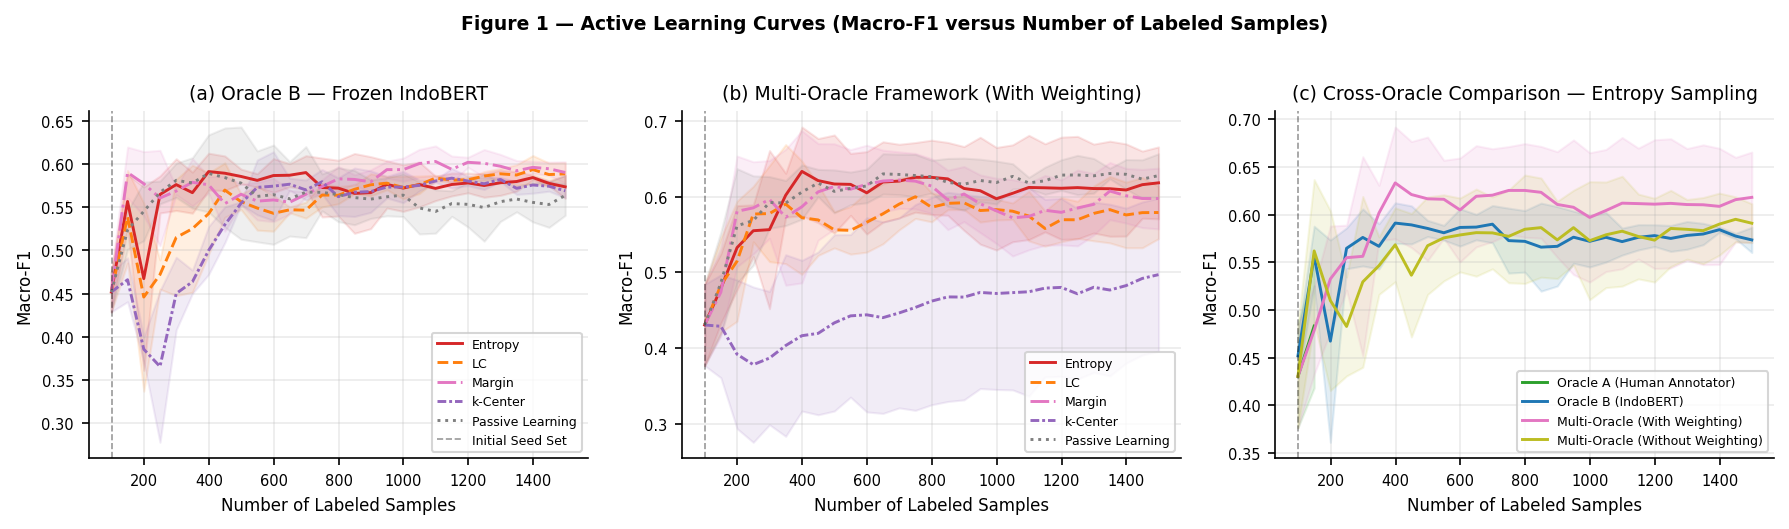

Figure 1 successfully saved.


In [24]:
# Shared helpers — used across all figures

def plot_c(ax, oracle, strat, lbl, ls, col):

    if (oracle, strat) not in SUMMARY:
        return

    df = SUMMARY[(oracle, strat)]

    x = df['n_labeled']
    y = df['f1_macro_mean']

    ax.plot(
        x, y,
        ls=ls,
        color=col,
        lw=1.4,
        label=lbl
    )

    if 'f1_macro_std' in df.columns:

        ax.fill_between(
            x,
            y - df['f1_macro_std'],
            y + df['f1_macro_std'],
            color=col,
            alpha=0.12
        )


sm = {
    'entropy':'Entropy',
    'least_confidence':'LC',
    'margin_sampling':'Margin',
    'kcenter_greedy':'k-Center',
    'random':'Passive Learning'
}

stys = [
    ('entropy','-','#d62728'),
    ('least_confidence','--','#ff7f0e'),
    ('margin_sampling','-.','#e377c2'),
    ('kcenter_greedy',(0,(3,1,1,1)),'#9467bd'),
    ('random',':','#7f7f7f')
]


# ── Figure 1 ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

fig.suptitle(
    'Figure 1 — Active Learning Curves (Macro-F1 versus Number of Labeled Samples)',
    fontsize=9,
    fontweight='bold',
    y=1.02
)


for s, ls, c in stys:
    plot_c(axes[0], 'indobert', s, sm[s], ls, c)

axes[0].set_title('(a) Oracle B — Frozen IndoBERT')

axes[0].set_ylabel('Macro-F1')
axes[0].set_xlabel('Number of Labeled Samples')

axes[0].axvline(
    x=N_SEED,
    color='black',
    ls='--',
    lw=0.8,
    alpha=0.4,
    label='Initial Seed Set'
)

axes[0].legend(fontsize=6)


for s, ls, c in stys:
    plot_c(axes[1], 'multi', s, sm[s], ls, c)

axes[1].set_title('(b) Multi-Oracle Framework (With Weighting)')

axes[1].set_xlabel('Number of Labeled Samples')

axes[1].axvline(
    x=N_SEED,
    color='black',
    ls='--',
    lw=0.8,
    alpha=0.4
)

axes[1].legend(fontsize=6)


for oracle, color, lbl in [
    ('manual','#2ca02c','Oracle A (Human Annotator)'),
    ('indobert','#1f77b4','Oracle B (IndoBERT)'),
    ('multi','#e377c2','Multi-Oracle (With Weighting)'),
    ('multi_nw','#bcbd22','Multi-Oracle (Without Weighting)')
]:

    plot_c(axes[2], oracle, 'entropy', lbl, '-', color)

axes[2].set_title('(c) Cross-Oracle Comparison — Entropy Sampling')

axes[2].set_xlabel('Number of Labeled Samples')

axes[2].axvline(
    x=N_SEED,
    color='black',
    ls='--',
    lw=0.8,
    alpha=0.4
)

axes[2].legend(fontsize=6)


for ax in axes:
    ax.set_ylabel('Macro-F1')


plt.tight_layout()

plt.savefig(
    'fig1_learning_curves.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig1_learning_curves.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 1 successfully saved.')

## Cell 23 — Figure 2: AULC Bar Chart (RQ1 — Efisiensi Label)
*Area Under the Learning Curve per strategi × oracle — ringkasan kuantitatif efisiensi label untuk tabel & narasi RQ1.*

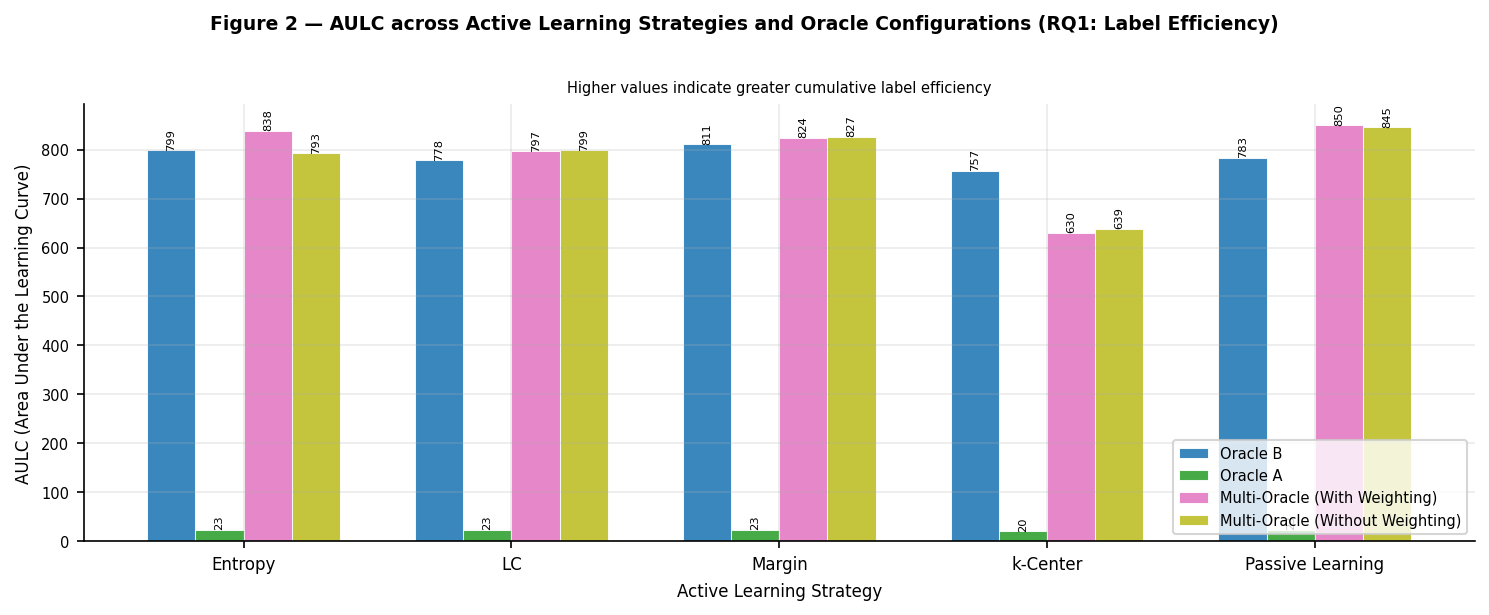

Figure 2 successfully saved.


In [25]:
# ── Figure 2: AULC per Strategy × Oracle ──────────────────────────────────────

oracles_plot = ['indobert', 'manual', 'multi', 'multi_nw']

oracle_labels_plot = [
    'Oracle B',
    'Oracle A',
    'Multi-Oracle (With Weighting)',
    'Multi-Oracle (Without Weighting)'
]

oracle_colors_plot = [
    '#1f77b4',
    '#2ca02c',
    '#e377c2',
    '#bcbd22'
]

strat_order = list(STRATEGIES.keys()) + ['random']

aulc_matrix = np.zeros((len(oracles_plot), len(strat_order)))

for i, oracle in enumerate(oracles_plot):

    for j, strat in enumerate(strat_order):

        key = (oracle, strat)

        if key in SUMMARY:
            aulc_matrix[i, j] = compute_auc(SUMMARY[key])


x_ = np.arange(len(strat_order))
bw_ = 0.18


fig, ax = plt.subplots(figsize=(10, 4))

fig.suptitle(
    'Figure 2 — AULC across Active Learning Strategies and Oracle Configurations '
    '(RQ1: Label Efficiency)',
    fontsize=9,
    fontweight='bold',
    y=1.01
)


for i, (oracle, lbl, col) in enumerate(
    zip(oracles_plot, oracle_labels_plot, oracle_colors_plot)
):

    offset = (i - 1.5) * bw_

    bars = ax.bar(
        x_ + offset,
        aulc_matrix[i],
        bw_,
        label=lbl,
        color=col,
        alpha=0.88,
        edgecolor='white',
        linewidth=0.5
    )

    # Annotate values above bars
    for bar in bars:

        h = bar.get_height()

        if h > 0:

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f'{h:.0f}',
                ha='center',
                va='bottom',
                fontsize=5.5,
                rotation=90
            )


ax.set_xticks(x_)

ax.set_xticklabels(
    [sm[s] for s in strat_order],
    fontsize=8
)

ax.set_ylabel('AULC (Area Under the Learning Curve)')

ax.set_xlabel('Active Learning Strategy')

ax.set_title(
    'Higher values indicate greater cumulative label efficiency',
    fontsize=7
)

ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()

plt.savefig(
    'fig2_aulc_barchart.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig2_aulc_barchart.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 2 successfully saved.')

## Cell 24 — Figure 3: Label Efficiency Plot (RQ1 — Penghematan Label)
*Berapa persen label yang dihemat AL vs Passive untuk mencapai 90% / 95% / 99% peak F1.*

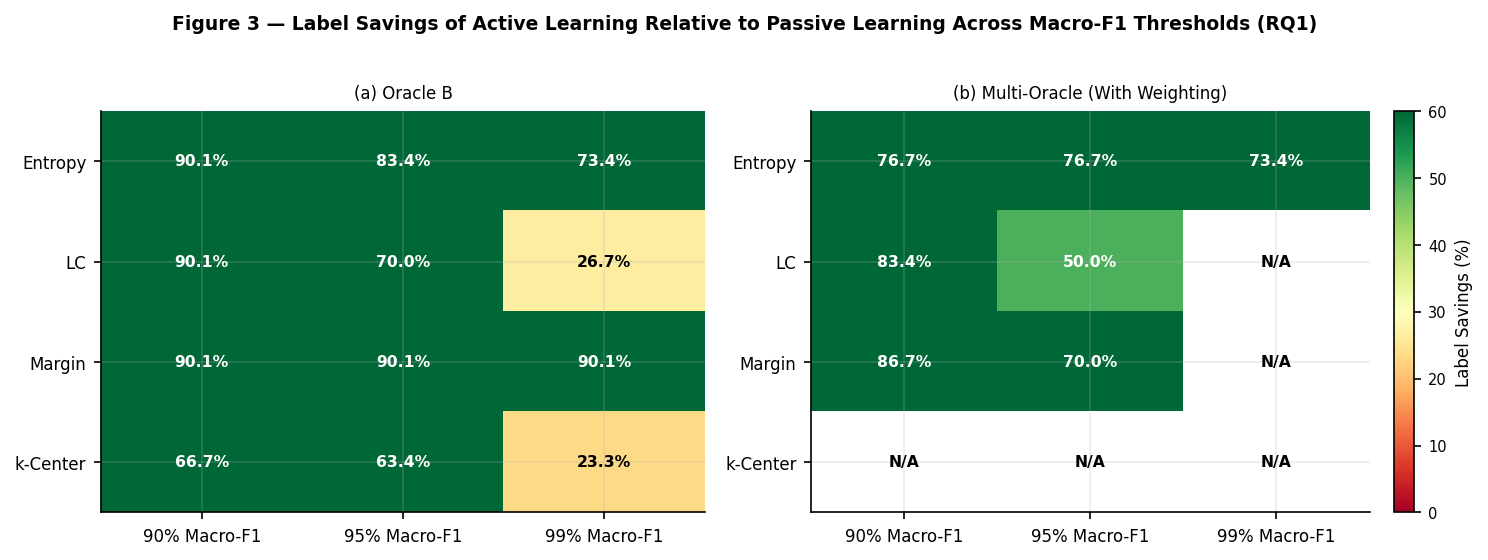

Figure 3 successfully saved.


In [26]:
# ── Figure 3: Label Efficiency Heatmap ────────────────────────────────────────

thresholds = [0.90, 0.95, 0.99]

oracles_eff = ['indobert', 'multi']

strats_eff = list(STRATEGIES.keys())  # excluding passive baseline


# Compute label savings (%) relative to passive learning
# for each oracle × strategy × threshold

eff_data = {}  # (oracle, strat, pct) → label saving (%)

for oracle in oracles_eff:

    key_p = (oracle, 'random')

    if key_p not in SUMMARY:
        continue

    pp = SUMMARY[key_p]['f1_macro_mean'].max()

    pn = int(SUMMARY[key_p]['n_labeled'].iloc[-1])

    for strat in strats_eff:

        for pct in thresholds:

            thr = pct * pp

            df = SUMMARY.get((oracle, strat), pd.DataFrame())

            hit = (
                df[df['f1_macro_mean'] >= thr]
                if len(df) else pd.DataFrame()
            )

            if len(hit):

                n_al = int(hit['n_labeled'].iloc[0])

                saving = (pn - n_al) / pn * 100

            else:
                saving = np.nan

            eff_data[(oracle, strat, pct)] = saving


# Construct heatmap matrices — one panel per oracle

fig, axes = plt.subplots(
    1,
    len(oracles_eff),
    figsize=(10, 3.6)
)

fig.suptitle(
    'Figure 3 — Label Savings of Active Learning Relative to Passive Learning '
    'Across Macro-F1 Thresholds (RQ1)',
    fontsize=9,
    fontweight='bold',
    y=1.02
)


oracle_name_map = {
    'indobert':'Oracle B',
    'multi':'Multi-Oracle (With Weighting)'
}


for ax, oracle in zip(axes, oracles_eff):

    mat = np.array([
        [
            eff_data.get((oracle, s, p), np.nan)
            for p in thresholds
        ]
        for s in strats_eff
    ])

    im = ax.imshow(
        mat,
        cmap='RdYlGn',
        vmin=0,
        vmax=60,
        aspect='auto'
    )

    ax.set_xticks(range(len(thresholds)))

    ax.set_xticklabels(
        [f'{int(p*100)}% Macro-F1' for p in thresholds],
        fontsize=8
    )

    ax.set_yticks(range(len(strats_eff)))

    ax.set_yticklabels(
        [sm[s] for s in strats_eff],
        fontsize=8
    )

    ax.set_title(
        f'({"ab"[oracles_eff.index(oracle)]}) {oracle_name_map[oracle]}',
        fontsize=8
    )

    # Annotate each cell

    for i in range(len(strats_eff)):

        for j in range(len(thresholds)):

            val = mat[i, j]

            txt = (
                f'{val:.1f}%'
                if not np.isnan(val)
                else 'N/A'
            )

            col = (
                'white'
                if (
                    not np.isnan(val)
                    and (val > 45 or val < 10)
                )
                else 'black'
            )

            ax.text(
                j,
                i,
                txt,
                ha='center',
                va='center',
                fontsize=7.5,
                color=col,
                fontweight='bold'
            )


plt.colorbar(
    im,
    ax=axes[-1],
    fraction=0.035,
    pad=0.04,
    label='Label Savings (%)'
)

plt.tight_layout()

plt.savefig(
    'fig3_label_efficiency.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig3_label_efficiency.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 3 successfully saved.')

## Cell 25 — Figure 4: Oracle Usage Stacked Bar (RQ2)
*Distribusi penggunaan Oracle A / B / C per strategi AL pada skema Multi-Oracle.*

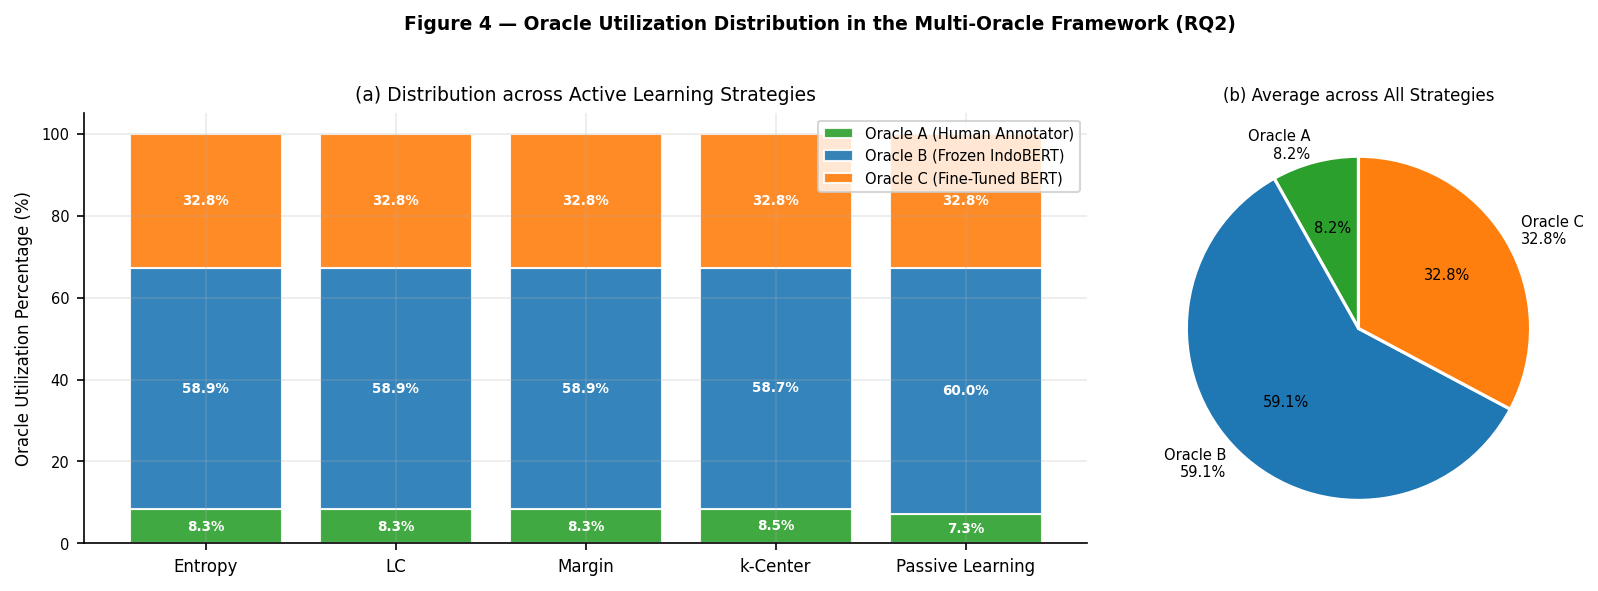

Figure 4 successfully saved.


In [27]:
# ── Figure 4: Oracle Usage Distribution (RQ2) ─────────────────────────────────

strat_order_rq2 = list(STRATEGIES.keys()) + ['random']

A_vals, B_vals, C_vals = [], [], []


for strat in strat_order_rq2:

    # Average oracle distribution across multiple random seeds

    a_list, b_list, c_list = [], [], []

    for rs in RUN_SEEDS:

        key = ('multi', strat, rs)

        if key not in ALL_RESULTS:
            continue

        src = Counter(ALL_RESULTS[key]['label_source'].values())

        tot = max(sum(src.values()), 1)

        a_list.append(src.get('A', 0) / tot * 100)
        b_list.append(src.get('B', 0) / tot * 100)
        c_list.append(src.get('C', 0) / tot * 100)

    A_vals.append(np.mean(a_list) if a_list else 0)
    B_vals.append(np.mean(b_list) if b_list else 0)
    C_vals.append(np.mean(c_list) if c_list else 0)


x_ = np.arange(len(strat_order_rq2))


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 3.8),
    gridspec_kw={'width_ratios': [2, 1]}
)

fig.suptitle(
    'Figure 4 — Oracle Utilization Distribution in the Multi-Oracle Framework (RQ2)',
    fontsize=9,
    fontweight='bold',
    y=1.02
)


# Left panel: stacked bar chart per strategy

ax = axes[0]

p1 = ax.bar(
    x_,
    A_vals,
    color='#2ca02c',
    label='Oracle A (Human Annotator)',
    alpha=0.9,
    edgecolor='w'
)

p2 = ax.bar(
    x_,
    B_vals,
    bottom=A_vals,
    color='#1f77b4',
    label='Oracle B (Frozen IndoBERT)',
    alpha=0.9,
    edgecolor='w'
)

C_bottom = [a + b for a, b in zip(A_vals, B_vals)]

p3 = ax.bar(
    x_,
    C_vals,
    bottom=C_bottom,
    color='#ff7f0e',
    label='Oracle C (Fine-Tuned BERT)',
    alpha=0.9,
    edgecolor='w'
)

ax.set_xticks(x_)

ax.set_xticklabels(
    [sm[s] for s in strat_order_rq2],
    fontsize=8
)

ax.set_ylabel('Oracle Utilization Percentage (%)')

ax.set_title('(a) Distribution across Active Learning Strategies')

ax.set_ylim(0, 105)

ax.legend(fontsize=7, loc='upper right')


# Annotate percentages inside bars

for i, (a, b, c) in enumerate(zip(A_vals, B_vals, C_vals)):

    if a > 2:

        ax.text(
            i,
            a / 2,
            f'{a:.1f}%',
            ha='center',
            va='center',
            fontsize=6.5,
            color='white',
            fontweight='bold'
        )

    if b > 2:

        ax.text(
            i,
            a + b / 2,
            f'{b:.1f}%',
            ha='center',
            va='center',
            fontsize=6.5,
            color='white',
            fontweight='bold'
        )

    if c > 2:

        ax.text(
            i,
            a + b + c / 2,
            f'{c:.1f}%',
            ha='center',
            va='center',
            fontsize=6.5,
            color='white',
            fontweight='bold'
        )


# Right panel: average utilization across all strategies (pie chart)

ax2 = axes[1]

avg_A = np.mean(A_vals)
avg_B = np.mean(B_vals)
avg_C = np.mean(C_vals)

wedge_props = {
    'edgecolor':'white',
    'linewidth':1.5
}

ax2.pie(
    [avg_A, avg_B, avg_C],
    labels=[
        f'Oracle A\n{avg_A:.1f}%',
        f'Oracle B\n{avg_B:.1f}%',
        f'Oracle C\n{avg_C:.1f}%'
    ],
    colors=['#2ca02c','#1f77b4','#ff7f0e'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':7},
    wedgeprops=wedge_props
)

ax2.set_title(
    '(b) Average across All Strategies',
    fontsize=8
)


plt.tight_layout()

plt.savefig(
    'fig4_oracle_usage.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig4_oracle_usage.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 4 successfully saved.')

## Cell 26 — Figure 5: Sample Weighting Comparison (RQ3)
*Perbandingan F1 Multi-Oracle dengan vs tanpa sample weight per strategi.*

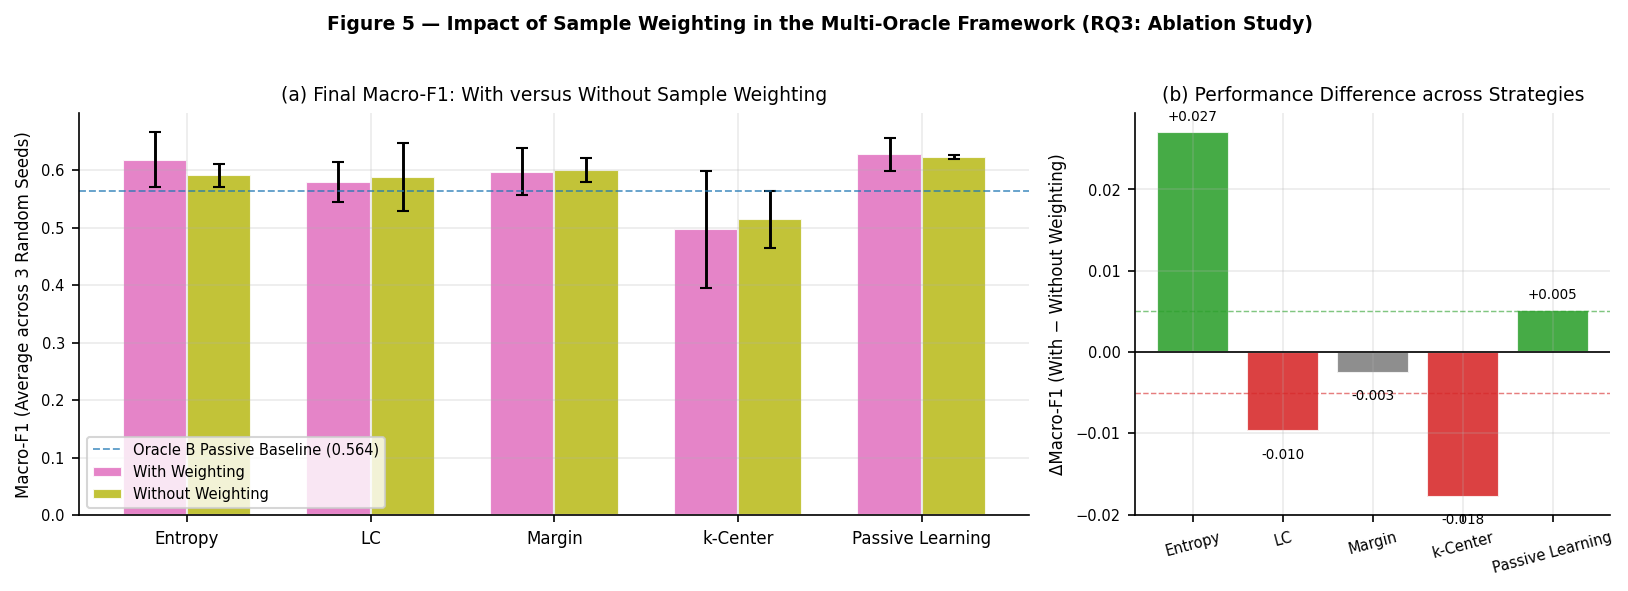

Figure 5 successfully saved.


In [28]:
# ── Figure 5: RQ3 — Sample Weighting Comparison ───────────────────────────────

strat_all = list(STRATEGIES.keys()) + ['random']


vals_w = [
    SUMMARY[('multi', s)]['f1_macro_mean'].iloc[-1]
    if ('multi', s) in SUMMARY else 0
    for s in strat_all
]

vals_nw = [
    SUMMARY[('multi_nw', s)]['f1_macro_mean'].iloc[-1]
    if ('multi_nw', s) in SUMMARY else 0
    for s in strat_all
]

std_w = [
    SUMMARY[('multi', s)]['f1_macro_std'].iloc[-1]
    if (
        ('multi', s) in SUMMARY
        and 'f1_macro_std' in SUMMARY[('multi', s)].columns
    )
    else 0
    for s in strat_all
]

std_nw = [
    SUMMARY[('multi_nw', s)]['f1_macro_std'].iloc[-1]
    if (
        ('multi_nw', s) in SUMMARY
        and 'f1_macro_std' in SUMMARY[('multi_nw', s)].columns
    )
    else 0
    for s in strat_all
]


x_ = np.arange(len(strat_all))

bw_ = 0.35


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 3.8),
    gridspec_kw={'width_ratios':[2,1]}
)

fig.suptitle(
    'Figure 5 — Impact of Sample Weighting in the Multi-Oracle Framework '
    '(RQ3: Ablation Study)',
    fontsize=9,
    fontweight='bold',
    y=1.02
)


# Left panel: grouped bar chart with error bars

ax = axes[0]

ax.bar(
    x_ - bw_ / 2,
    vals_w,
    bw_,
    yerr=std_w,
    label='With Weighting',
    color='#e377c2',
    alpha=0.9,
    edgecolor='w',
    capsize=3
)

ax.bar(
    x_ + bw_ / 2,
    vals_nw,
    bw_,
    yerr=std_nw,
    label='Without Weighting',
    color='#bcbd22',
    alpha=0.9,
    edgecolor='w',
    capsize=3
)

ax.set_xticks(x_)

ax.set_xticklabels(
    [sm[s] for s in strat_all],
    fontsize=8
)

ax.set_ylabel('Macro-F1 (Average across 3 Random Seeds)')

ax.set_title(
    '(a) Final Macro-F1: With versus Without Sample Weighting'
)

ax.legend(fontsize=7)


# Passive-learning baseline from Oracle B

if ('indobert', 'random') in SUMMARY:

    bl = SUMMARY[('indobert', 'random')]['f1_macro_mean'].iloc[-1]

    ax.axhline(
        y=bl,
        color='#1f77b4',
        ls='--',
        lw=0.9,
        alpha=0.7,
        label=f'Oracle B Passive Baseline ({bl:.3f})'
    )

    ax.legend(fontsize=7)


# Right panel: delta comparison
# (with weighting − without weighting)

ax2 = axes[1]

deltas = [w - nw for w, nw in zip(vals_w, vals_nw)]

cols_d = [
    '#2ca02c'
    if d > 0.005
    else (
        '#d62728'
        if d < -0.005
        else '#7f7f7f'
    )
    for d in deltas
]

ax2.bar(
    x_,
    deltas,
    color=cols_d,
    alpha=0.88,
    edgecolor='w'
)

ax2.axhline(
    y=0,
    color='black',
    lw=0.8
)

ax2.axhline(
    y=0.005,
    color='#2ca02c',
    ls='--',
    lw=0.7,
    alpha=0.6
)

ax2.axhline(
    y=-0.005,
    color='#d62728',
    ls='--',
    lw=0.7,
    alpha=0.6
)

ax2.set_xticks(x_)

ax2.set_xticklabels(
    [sm[s] for s in strat_all],
    fontsize=7,
    rotation=15
)

ax2.set_ylabel('ΔMacro-F1 (With − Without Weighting)')

ax2.set_title('(b) Performance Difference across Strategies')


for i, d in enumerate(deltas):

    ax2.text(
        i,
        d + (0.001 if d >= 0 else -0.002),
        f'{d:+.3f}',
        ha='center',
        va='bottom' if d >= 0 else 'top',
        fontsize=6.5
    )


plt.tight_layout()

plt.savefig(
    'fig5_rq3_weighting.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig5_rq3_weighting.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 5 successfully saved.')

## Cell 27 — Figure 6: Confusion Matrix Model Terbaik
*Confusion matrix absolut & ternormalisasi untuk model dengan F1 tertinggi.*

Best-performing model: oracle = multi | strategy = random | Macro-F1 = 0.6277

--- Classification Performance Report ---
              precision    recall  f1-score   support

    Negative       0.83      0.40      0.54       279
     Neutral       0.57      0.77      0.65       280
    Positive       0.55      0.73      0.63       141

    accuracy                           0.61       700
   macro avg       0.65      0.63      0.61       700
weighted avg       0.67      0.61      0.60       700



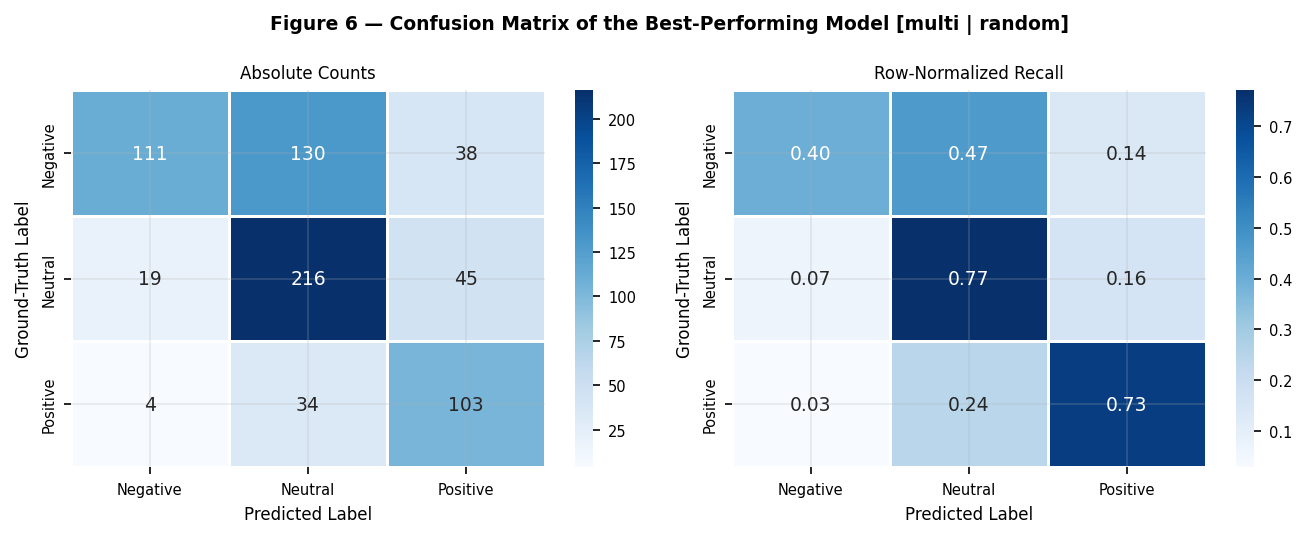

Figure 6 successfully saved.


In [29]:
# ── Figure 6: Confusion Matrix of the Best-Performing Model ───────────────────

best_row = df_final.sort_values('Macro F1', ascending=False).iloc[0]

ob, sb = best_row['Oracle'], best_row['Strategy']

print(
    f'Best-performing model: '
    f'oracle = {ob} | strategy = {sb} | '
    f'Macro-F1 = {best_row["Macro F1"]:.4f}'
)

key_best = next(
    (
        (ob, sb, rs)
        for rs in RUN_SEEDS
        if (ob, sb, rs) in ALL_RESULTS
    ),
    None
)


if key_best:

    y_pred = ALL_RESULTS[key_best]['final_clf'].predict(test_embeddings)

    print('\n--- Classification Performance Report ---')

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=LABEL_ORDER,
            zero_division=0
        )
    )


    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

    fig.suptitle(
        f'Figure 6 — Confusion Matrix of the Best-Performing Model '
        f'[{ob} | {sb}]',
        fontsize=9,
        fontweight='bold'
    )


    for ax, (nm, fmt, ttl) in zip(
        axes,
        [
            (None, 'd', 'Absolute Counts'),
            ('true', '.2f', 'Row-Normalized Recall')
        ]
    ):

        cm = confusion_matrix(
            y_test,
            y_pred,
            normalize=nm
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt=fmt,
            cmap='Blues',
            xticklabels=LABEL_ORDER,
            yticklabels=LABEL_ORDER,
            ax=ax,
            linewidths=0.5,
            cbar=True,
            annot_kws={'size': 9}
        )

        ax.set_title(ttl, fontsize=8)

        ax.set_xlabel('Predicted Label')

        ax.set_ylabel('Ground-Truth Label')


    plt.tight_layout()

    plt.savefig(
        'fig6_confusion.pdf',
        bbox_inches='tight',
        dpi=300
    )

    plt.savefig(
        'fig6_confusion.png',
        bbox_inches='tight',
        dpi=300
    )

    plt.show()

    print('Figure 6 successfully saved.')

else:

    print('Warning: the corresponding result key was not found in ALL_RESULTS.')

## Cell 28 — Figure 7: Per-class F1 Breakdown
*Dekomposisi F1 per kelas (Negatif/Netral/Positif) untuk semua oracle × strategi terbaik — penting untuk dataset sentimen yang imbalanced.*

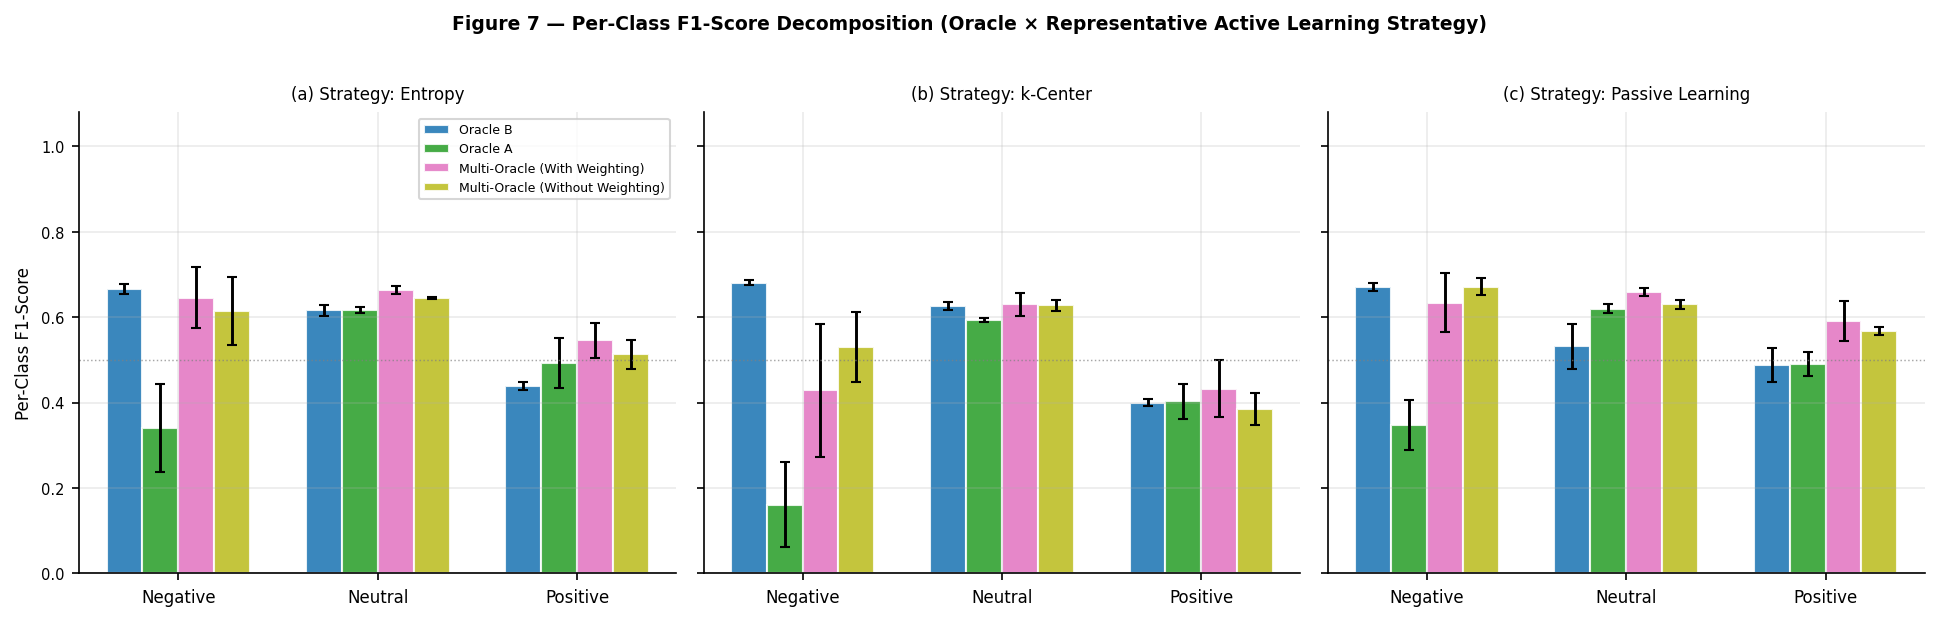

Figure 7 successfully saved.

All figures (Figures 1–7) have been successfully generated.


In [30]:
# ── Figure 7: Per-Class F1-Score Breakdown ────────────────────────────────────

# Extract per-class F1-scores from the final stage of each experiment

oracles_pc = ['indobert', 'manual', 'multi', 'multi_nw']

labels_pc = [
    'Oracle B',
    'Oracle A',
    'Multi-Oracle (With Weighting)',
    'Multi-Oracle (Without Weighting)'
]

colors_pc = [
    '#1f77b4',
    '#2ca02c',
    '#e377c2',
    '#bcbd22'
]

strats_best = [
    'entropy',
    'kcenter_greedy',
    'random'
]  # representative strategies

class_names = [
    'Negative',
    'Neutral',
    'Positive'
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4.0),
    sharey=True
)

fig.suptitle(
    'Figure 7 — Per-Class F1-Score Decomposition '
    '(Oracle × Representative Active Learning Strategy)',
    fontsize=9,
    fontweight='bold',
    y=1.02
)


bw_ = 0.18


for ax_i, strat in enumerate(strats_best):

    ax = axes[ax_i]

    x_ = np.arange(3)  # three sentiment classes


    for oi, (oracle, lbl, col) in enumerate(
        zip(oracles_pc, labels_pc, colors_pc)
    ):

        # Average per-class F1-score across random seeds
        # at the final labeling stage

        f1c = []

        for rs in RUN_SEEDS:

            key = (oracle, strat, rs)

            if key not in ALL_RESULTS:
                continue

            hist = pd.DataFrame(ALL_RESULTS[key]['history'])

            last = hist.iloc[-1]

            f1c.append([
                last.get(f'f1_class{k}', 0)
                for k in range(3)
            ])


        if not f1c:
            continue


        vals = np.mean(f1c, axis=0)

        errs = np.std(f1c, axis=0)

        offset = (oi - 1.5) * bw_


        ax.bar(
            x_ + offset,
            vals,
            bw_,
            yerr=errs,
            label=lbl,
            color=col,
            alpha=0.88,
            edgecolor='w',
            capsize=2.5
        )


    ax.set_xticks(x_)

    ax.set_xticklabels(
        class_names,
        fontsize=8
    )

    ax.set_title(
        f'({"abc"[ax_i]}) Strategy: {sm[strat]}',
        fontsize=8
    )

    ax.set_ylim(0, 1.08)


    if ax_i == 0:

        ax.set_ylabel('Per-Class F1-Score')

        ax.legend(
            fontsize=6,
            loc='upper right'
        )


    # Reference line at F1 = 0.5

    ax.axhline(
        y=0.5,
        color='gray',
        ls=':',
        lw=0.7,
        alpha=0.7
    )


plt.tight_layout()

plt.savefig(
    'fig7_perclass_f1.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.savefig(
    'fig7_perclass_f1.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('Figure 7 successfully saved.')

print('\nAll figures (Figures 1–7) have been successfully generated.')

## Cell 29 — Export & Simpan ke Google Drive

In [31]:
import shutil

hist_rows=[]
for (oracle,strat,rs),res in ALL_RESULTS.items():
    for h in res['history']:
        hist_rows.append({'oracle':oracle,'strategy':strat,'run_seed':rs,**h})
df_hist=pd.DataFrame(hist_rows)
df_hist.to_csv('al_history_full.csv',index=False)
df_final.to_csv('al_summary.csv',index=False)

with pd.ExcelWriter('results_mbg_al_v5.xlsx',engine='openpyxl') as xw:
    df_final.to_excel(xw,sheet_name='Summary',index=False)
    df_hist.to_excel(xw,sheet_name='History',index=False)

print('✅ File CSV & Excel tersimpan.')

out_dir = OUTPUT_DIR
os.makedirs(out_dir,exist_ok=True)
for fn in ['al_summary.csv','al_history_full.csv','results_mbg_al_v5.xlsx']:
    shutil.copy(fn,f'{out_dir}/{fn}')

# Simpan semua figure (1–7) + EDA
fig_names = [
    'fig0_eda',
    'fig1_learning_curves',
    'fig2_aulc_barchart',
    'fig3_label_efficiency',
    'fig4_oracle_usage',
    'fig5_rq3_weighting',
    'fig6_confusion',
    'fig7_perclass_f1',
]
for f in fig_names:
    for ext in ['pdf','png']:
        src_f = f'{f}.{ext}'
        if os.path.exists(src_f):
            shutil.copy(src_f, f'{out_dir}/{src_f}')

print(f'✅ Semua output (CSV, Excel, 8 figure) disalin ke: {out_dir}')
print(f'   Figure tersimpan: {[f for f in fig_names if os.path.exists(f+".png")]}')

if IN_COLAB:
    from google.colab import files
    for fn in ['al_summary.csv','results_mbg_al_v5.xlsx']:
        try: files.download(fn)
        except Exception: pass

✅ File CSV & Excel tersimpan.
✅ Semua output (CSV, Excel, 8 figure) disalin ke Google Drive: /content/drive/MyDrive/MBG_AL/output_v5
   Figure tersimpan: ['fig0_eda', 'fig1_learning_curves', 'fig2_aulc_barchart', 'fig3_label_efficiency', 'fig4_oracle_usage', 'fig5_rq3_weighting', 'fig6_confusion', 'fig7_perclass_f1']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>